# Predictive Analytics Mini-Study
**SafeX Solutions — Business Automation Research (Week 2)**
**Developer:** Ali Zaib | AI/ML Intern

This notebook is the exploratory / documentation companion to the
`predictive_analytics` module (`engine.py` + `ui.py`). It walks through
both prediction tasks end-to-end with sample input and output:

1. **Demand forecasting** — regression model predicting next-month demand
   from a small sample of monthly business history.
2. **Churn prediction** — classification model predicting whether a
   customer is likely to churn, from a small sample customer dataset.

Both datasets are **synthetic sample data** (generated with realistic
trend/seasonality/behavioral structure), since no proprietary SafeX
production data was available for this internship prototype. The same
`PredictiveAnalyticsEngine` class used here powers the Streamlit UI tab
in the shared automation suite (`src/app.py`).


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))  # repo root, so `src` is importable
import pandas as pd
import matplotlib.pyplot as plt

from src.modules.predictive_analytics.engine import PredictiveAnalyticsEngine

engine = PredictiveAnalyticsEngine()
pd.set_option("display.max_columns", None)


## Part 1 — Demand Forecasting
### 1.1 Sample input: raw demand history

In [2]:
demand_df = engine.load_demand_data()
print("Shape:", demand_df.shape)
demand_df.head(10)


Shape: (42, 6)


,month_index,month_of_year,marketing_spend,price_index,promo_flag,demand_units
0,1,1,2122.0,96.7,0,599
1,2,2,1584.0,101.2,0,534
2,3,3,2300.0,100.6,1,653
3,4,4,2376.0,101.1,0,651
4,5,5,1220.0,104.4,1,657
5,6,6,1479.0,101.1,0,639
6,7,7,2051.0,103.4,0,699
7,8,8,1874.0,100.3,0,666
8,9,9,1993.0,101.4,0,620
9,10,10,1659.0,103.2,0,623


In [3]:
demand_df.tail(5)


,month_index,month_of_year,marketing_spend,price_index,promo_flag,demand_units
37,38,2,1664.0,98.5,0,769
38,39,3,1670.0,102.3,1,862
39,40,4,2260.0,96.7,0,875
40,41,5,2297.0,98.2,0,937
41,42,6,2217.0,98.1,1,971


### 1.2 Quick exploratory look at the trend + seasonality

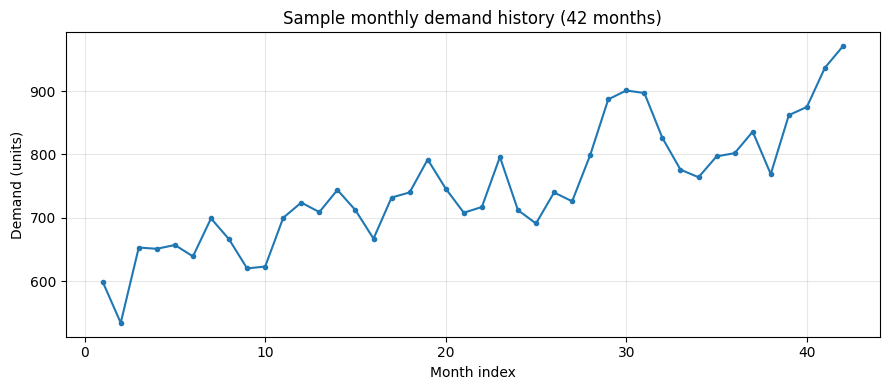

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(demand_df["month_index"], demand_df["demand_units"], marker="o", markersize=3)
ax.set_xlabel("Month index")
ax.set_ylabel("Demand (units)")
ax.set_title("Sample monthly demand history (42 months)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1.3 Train a regression model

We hold out the **last 6 months** as a test set (a time-based split,
since this is a time series — a random shuffle would leak future
information into training).


In [5]:
linear_metrics = engine.train_demand_model("linear")
linear_metrics


{'model_type': 'linear',
 'n_train': 33,
 'n_test': 6,
 'mae': 21.04,
 'rmse': 24.53,
 'r2': 0.861,
 'test_months': [37, 38, 39, 40, 41, 42],
 'test_actual': [836, 769, 862, 875, 937, 971],
 'test_predicted': [819.9, 793.9, 828.4, 887.9, 899.1, 970.1]}

In [6]:
rf_metrics = engine.train_demand_model("random_forest")
rf_metrics


{'model_type': 'random_forest',
 'n_train': 33,
 'n_test': 6,
 'mae': 68.46,
 'rmse': 77.25,
 'r2': -0.378,
 'test_months': [37, 38, 39, 40, 41, 42],
 'test_actual': [836, 769, 862, 875, 937, 971],
 'test_predicted': [798.5, 788.5, 773.3, 825.0, 845.8, 847.2]}

**Observation:** Linear Regression clearly outperforms the Random
Forest on this holdout (higher R², lower MAE/RMSE). This is an expected,
useful finding: tree-based models cannot extrapolate beyond the range of
values seen during training, so they under-predict an ongoing upward
trend. Linear Regression captures the trend term directly and
extrapolates it correctly. For this dataset we retrain and use the
linear model going forward.

In [7]:
engine.train_demand_model("linear")
forecast_df = engine.forecast_demand(periods=6)
forecast_df


,month_index,month_of_year,forecast_demand
0,43,7,915.3
1,44,8,893.6
2,45,9,882.1
3,46,10,867.2
4,47,11,853.8
5,48,12,848.3


### 1.4 Sample output: actual vs. predicted (holdout) and the forward forecast

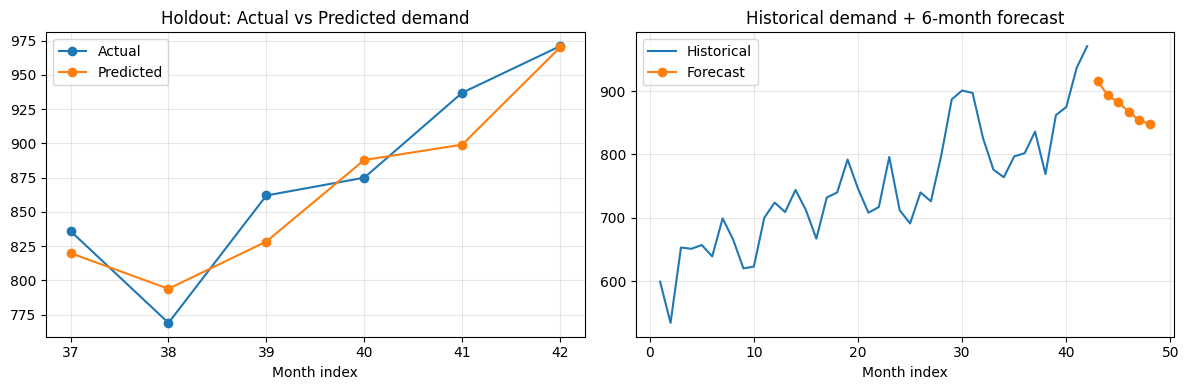

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(linear_metrics["test_months"], linear_metrics["test_actual"], marker="o", label="Actual")
axes[0].plot(linear_metrics["test_months"], linear_metrics["test_predicted"], marker="o", label="Predicted")
axes[0].set_title("Holdout: Actual vs Predicted demand")
axes[0].set_xlabel("Month index")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(demand_df["month_index"], demand_df["demand_units"], label="Historical")
axes[1].plot(forecast_df["month_index"], forecast_df["forecast_demand"], marker="o", label="Forecast")
axes[1].set_title("Historical demand + 6-month forecast")
axes[1].set_xlabel("Month index")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Part 2 — Churn Prediction
### 2.1 Sample input: raw customer sample data

In [9]:
churn_df = engine.load_churn_data()
print("Shape:", churn_df.shape)
print("Churn rate:", churn_df["churned"].mean().round(3))
churn_df.head(10)


Shape: (300, 7)
Churn rate: 0.203


,customer_id,tenure_months,monthly_spend,support_tickets,satisfaction_score,active_discount,churned
0,CUST-0001,37,131.97,0,3,0,0
1,CUST-0002,31,115.32,0,6,0,0
2,CUST-0003,54,93.17,5,4,1,1
3,CUST-0004,16,132.32,0,10,0,0
4,CUST-0005,59,93.17,1,5,0,1
5,CUST-0006,56,104.84,1,10,0,0
6,CUST-0007,11,71.10,2,7,0,0
7,CUST-0008,10,82.00,3,1,0,1
8,CUST-0009,32,59.08,3,3,0,1
9,CUST-0010,3,109.69,2,8,1,0


### 2.2 Quick exploratory look — does satisfaction relate to churn?

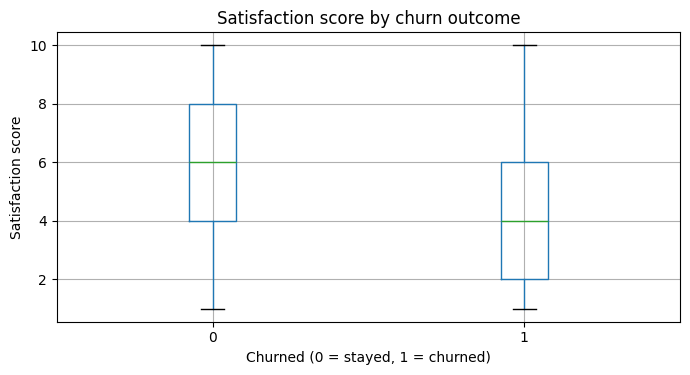

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
churn_df.boxplot(column="satisfaction_score", by="churned", ax=ax)
ax.set_xlabel("Churned (0 = stayed, 1 = churned)")
ax.set_ylabel("Satisfaction score")
plt.title("Satisfaction score by churn outcome")
plt.suptitle("")
plt.tight_layout()
plt.show()


### 2.3 Train a classifier

A 75/25 stratified train/test split (stratified so the ~20% churn rate
is preserved in both splits).


In [11]:
logistic_metrics = engine.train_churn_model("logistic")
logistic_metrics


{'model_type': 'logistic',
 'n_train': 225,
 'n_test': 75,
 'accuracy': 0.827,
 'precision': 0.625,
 'recall': 0.333,
 'f1': 0.435,
 'confusion_matrix': [[57, 3], [10, 5]],
 'feature_importance': {'tenure_months': 0.053,
  'monthly_spend': 0.007,
  'support_tickets': 0.563,
  'satisfaction_score': 0.243,
  'active_discount': 0.512}}

In [12]:
rf_churn_metrics = engine.train_churn_model("random_forest")
rf_churn_metrics


{'model_type': 'random_forest',
 'n_train': 225,
 'n_test': 75,
 'accuracy': 0.827,
 'precision': 0.667,
 'recall': 0.267,
 'f1': 0.381,
 'confusion_matrix': [[58, 2], [11, 4]],
 'feature_importance': {'tenure_months': 0.369,
  'monthly_spend': 0.226,
  'support_tickets': 0.182,
  'satisfaction_score': 0.194,
  'active_discount': 0.029}}

### 2.4 Sample output: feature importance

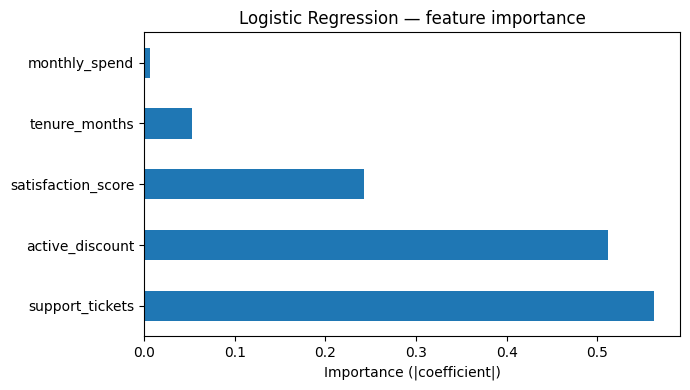

In [13]:
engine.train_churn_model("logistic")  # re-fit so the engine holds the logistic model for scoring below
importance = pd.Series(logistic_metrics["feature_importance"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot.barh(ax=ax)
ax.set_xlabel("Importance (|coefficient|)")
ax.set_title("Logistic Regression — feature importance")
plt.tight_layout()
plt.show()


**Observation:** Support ticket volume and whether a discount is
active are the strongest signals for churn in this sample, followed by
satisfaction score — all directionally sensible (more support tickets
and no discount increase churn risk; higher satisfaction reduces it).


### 2.5 Sample output: scoring individual customers

In [14]:
high_risk_customer = {
    "tenure_months": 2,
    "monthly_spend": 55,
    "support_tickets": 6,
    "satisfaction_score": 2,
    "active_discount": 0,
}
low_risk_customer = {
    "tenure_months": 50,
    "monthly_spend": 90,
    "support_tickets": 0,
    "satisfaction_score": 9,
    "active_discount": 1,
}

print("High-risk profile ->", engine.predict_churn(high_risk_customer))
print("Low-risk profile  ->", engine.predict_churn(low_risk_customer))


High-risk profile -> {'churn_probability': 0.956, 'label': 'Likely to churn'}
Low-risk profile  -> {'churn_probability': 0.008, 'label': 'Likely to stay'}


---
## Summary

- **Demand forecasting:** Linear Regression trained on lag/seasonal
  features forecasts monthly demand with a solid holdout R² (see Part
  1.3), and correctly continues the sample's upward trend and
  seasonality into the 6-month forecast. Random Forest under-forecasts
  because it cannot extrapolate past the training range — a genuine,
  worth-noting limitation of tree-based models for trending time series.
- **Churn prediction:** Both Logistic Regression and Random Forest
  reach comparable accuracy on the sample data; Logistic Regression's
  coefficients give directly interpretable churn drivers (support
  tickets and lack of discount are the top risk factors here).
- Both models are exposed through `PredictiveAnalyticsEngine` and
  wired into the shared Streamlit suite (`predictive_analytics` tab),
  where a user can retrain either model and score new customers
  interactively.

**Limitations:** both datasets are synthetic samples generated for this
prototype (no proprietary SafeX data was available), so the specific
numbers here are illustrative of the *method*, not real SafeX KPIs.
Swapping in real historical sales/CRM data would require no changes to
`engine.py` beyond matching column names.
